# Lecture 12 — Deep Learning for Time Series: Convolutional Models
**Course:** MLTS (Machine Learning for Time Series)

## Learning objectives
- Understand *why* CNNs are an attractive alternative to RNN/LSTM for sequences (parallelism, long range, no vanishing-through-time).
- Implement the **discrete convolution** (1D and 2D) from scratch and verify against `scipy.signal`.
- Implement **max-pooling** and the two padding modes (`valid` vs `same`) and see how they shape the output size.
- Demonstrate the **translation-equivariance** property of convolutional layers numerically.
- Build a small **1D-CNN classifier** on synthetic time series with PyTorch.
- Implement **causal (temporal) convolution** with **dilation**, the building block of TCNs, and verify there is no information leakage from the future.

> Lecture took the deep-learning route (justifies `torch` in the otherwise NumPy/SciPy stack). Implementations follow the slides' notation: `K` for kernel/filter, `H` for output feature map, dilation factor `d`.

In [1]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

rng = np.random.default_rng(seed=42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("numpy", np.__version__, "| torch", torch.__version__)

numpy 2.4.4 | torch 2.11.0+cu130


## 1. Motivation — why CNNs for sequences?

The slides list four pain-points of RNN/LSTM:
1. **No parallelism** — each timestep depends on the previous hidden state.
2. **Long sequences** are slow and memory-heavy.
3. **Vanishing/exploding gradients** through time (LSTM mitigates, doesn't eliminate).
4. **Long-range dependencies** are hard to learn in practice.

CNNs sidestep (1) and (2) directly: every output position can be computed in parallel, and the receptive field grows with depth/dilation rather than recurrence depth. They lose strict causality (a vanilla conv looks both ways), which is exactly what **causal convolutions** in TCNs fix.

We start with the simplest possible numerical demonstration of *parallelism*: convolving a long signal with a small kernel.

In [2]:
# Quick wall-clock comparison: a simple "1-step recurrence" vs a NumPy convolution
# (NOT a fair training comparison — just illustrating that conv is one vectorised op
# while a recurrence is a Python-level loop.)
import time

T = 200_000
x = rng.standard_normal(T)
k = np.array([0.2, 0.5, 0.3])

t0 = time.perf_counter()
y_rec = np.empty(T)
y_rec[0] = x[0]
for t in range(1, T):
    y_rec[t] = 0.9 * y_rec[t-1] + 0.1 * x[t]   # toy AR(1)-style recurrence
t_rec = time.perf_counter() - t0

t0 = time.perf_counter()
y_conv = np.convolve(x, k, mode='same')
t_conv = time.perf_counter() - t0

print(f"sequential recurrence over T={T}: {t_rec*1e3:6.1f} ms")
print(f"vectorised convolution    over T={T}: {t_conv*1e3:6.1f} ms")
print(f"speed-up ≈ {t_rec/t_conv:.0f}× — this is the practical appeal of CNNs.")

sequential recurrence over T=200000:  110.1 ms
vectorised convolution    over T=200000:    1.2 ms
speed-up ≈ 89× — this is the practical appeal of CNNs.


**Takeaway.** A single conv kernel on a 200k-long series is orders of magnitude faster than the equivalent Python-level recurrence — and on GPU the gap widens further. This is why CNN-based architectures (TCNs, WaveNet, etc.) became attractive for long sequences.

## 2. The discrete convolution, from scratch

The slide writes (in 1D):
$$ (x * k)[n] \;=\; \sum_{m=-\infty}^{+\infty} x[m]\, k[n-m]. $$

In deep-learning frameworks what is *actually* computed is **cross-correlation** (kernel is **not** flipped). We implement both and show the difference is exactly a kernel-flip.

In [3]:
def conv1d_scratch(x, k, mode='valid'):
    # Cross-correlation (the DL convention). mode in {'valid', 'same'}.
    x = np.asarray(x, dtype=float); k = np.asarray(k, dtype=float)
    n, m = len(x), len(k)
    if mode == 'same':
        pad = (m - 1) // 2
        x = np.pad(x, (pad, m - 1 - pad))   # symmetric zero-pad
        n = len(x)
    out_len = n - m + 1
    y = np.empty(out_len)
    for i in range(out_len):
        y[i] = np.dot(x[i:i+m], k)          # Σ x[i+j] * k[j]
    return y

# Sanity check vs scipy (which also does correlation when called via correlate)
x = np.array([1, 2, 3, 4, 5], dtype=float)
k = np.array([0.5, 1.0, -0.5], dtype=float)
y_mine   = conv1d_scratch(x, k, mode='valid')
y_scipy  = scipy.signal.correlate(x, k, mode='valid')   # same convention
y_npconv = np.convolve(x, k[::-1], mode='valid')        # convolve flips kernel

print("scratch  :", y_mine)
print("scipy    :", y_scipy)
print("np.conv  :", y_npconv, "  (np.convolve flips k, so we feed k[::-1])")
print("max |err|:", np.max(np.abs(y_mine - y_scipy)))

scratch  : [1. 2. 3.]
scipy    : [1. 2. 3.]
np.conv  : [1. 2. 3.]   (np.convolve flips k, so we feed k[::-1])
max |err|: 0.0


**Reproduces the slide example.** The slide computes $h_1 = w_1 x_1 + w_2 x_2 + w_3 x_3$ with $w=[0.5,1,-0.5]$ on the window $[1,2,3]$ giving $0.5 + 2 - 1.5 = 1.0$. ✓

In [4]:
# 2D version — reproduces the slide's 5x5 input × 3x3 kernel example
def conv2d_scratch(X, K):
    # Valid 2D cross-correlation.
    H, W = X.shape; kh, kw = K.shape
    out = np.empty((H - kh + 1, W - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return out

X = rng.integers(0, 5, size=(5, 5)).astype(float)
K = rng.standard_normal((3, 3))

H_mine  = conv2d_scratch(X, K)
H_scipy = scipy.signal.correlate2d(X, K, mode='valid')

print("max |error| vs scipy.correlate2d:", np.abs(H_mine - H_scipy).max())
print("output shape:", H_mine.shape, " (expected (5-3+1, 5-3+1) = (3, 3))")

max |error| vs scipy.correlate2d: 1.7763568394002505e-15
output shape: (3, 3)  (expected (5-3+1, 5-3+1) = (3, 3))


**Takeaway.** The 2D convolution slides through the input and computes one dot product per position. Output size is `(H - kh + 1, W - kw + 1)` in `valid` mode — exactly the dimensionality-reduction that motivates padding (next).

## 3. Pooling and padding

**Padding** adds zeros so output size matches input size: with kernel size $m$ and `same` mode, pad $\lfloor(m-1)/2\rfloor$ on each side.

**Pooling** downsamples (typically by 2): max-pool keeps the strongest activation in each window. The slide uses 2×2 max-pool which halves both spatial dims.

In [5]:
def maxpool2d_scratch(X, k=2, stride=2):
    H, W = X.shape
    out_h, out_w = (H - k) // stride + 1, (W - k) // stride + 1
    out = np.empty((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = X[i*stride:i*stride+k, j*stride:j*stride+k].max()
    return out

X4 = rng.integers(0, 10, size=(4, 4))
P  = maxpool2d_scratch(X4, k=2, stride=2)

# Verify against torch
X4_t = torch.tensor(X4, dtype=torch.float32)[None, None]   # (N, C, H, W)
P_torch = F.max_pool2d(X4_t, kernel_size=2, stride=2).squeeze().numpy()

print("input X:\n", X4)
print("max-pool 2×2 (scratch):\n", P)
print("max-pool 2×2 (torch  ):\n", P_torch)
print("match:", np.allclose(P, P_torch))

input X:
 [[7 9 7 5]
 [0 3 2 1]
 [1 4 8 8]
 [7 3 5 1]]
max-pool 2×2 (scratch):
 [[9. 7.]
 [7. 8.]]
max-pool 2×2 (torch  ):
 [[9. 7.]
 [7. 8.]]
match: True


In [6]:
# Padding demo: same vs valid on a 1D signal
sig = np.arange(1, 8, dtype=float)        # length 7
ker = np.array([1, 1, 1]) / 3             # 3-tap moving average

valid = conv1d_scratch(sig, ker, mode='valid')
same  = conv1d_scratch(sig, ker, mode='same')

print(f"input  length: {len(sig)}")
print(f"valid  length: {len(valid)}  ->  {valid}")
print(f"same   length: {len(same)}  ->  {np.round(same, 3)}")
print("Note: 'same' shrinks the boundary values toward 0 because of the zero padding.")

input  length: 7
valid  length: 5  ->  [2. 3. 4. 5. 6.]
same   length: 7  ->  [1.    2.    3.    4.    5.    6.    4.333]
Note: 'same' shrinks the boundary values toward 0 because of the zero padding.


**Takeaway.** `valid` is honest but loses $m-1$ samples; `same` preserves length at the cost of a *biased* response near the edges (the edge values get convolved with literal zeros). This matters at the input/output edges of TCNs — the standard trick is to left-pad only (causal padding) so the bias falls outside the prediction horizon.

## 4. Translation equivariance

A function $f$ is **equivariant** to translation $\tau$ if $f(\tau(x)) = \tau(f(x))$. For a convolution with kernel $k$, shifting the input by $s$ samples shifts the output by exactly $s$ samples (modulo padding effects). We verify this empirically.

max |y2 - shift(y1)| in interior: 0.00e+00


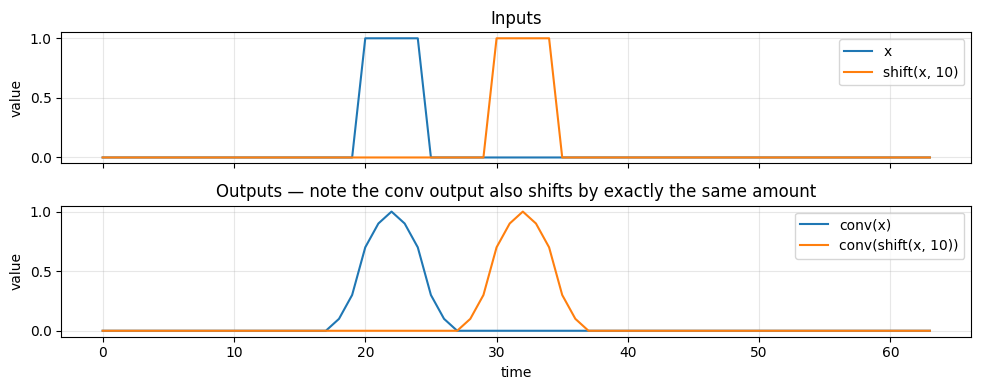

In [7]:
# Build a signal with a single bump, convolve with a smoothing kernel,
# then shift the input and convolve again. Check the output also shifts.
T = 64
x1 = np.zeros(T); x1[20:25] = 1.0          # bump at position 20-24
shift = 10
x2 = np.roll(x1, shift)                     # bump at position 30-34

k = np.array([0.1, 0.2, 0.4, 0.2, 0.1])    # small smoothing kernel
y1 = conv1d_scratch(x1, k, mode='same')
y2 = conv1d_scratch(x2, k, mode='same')

# Equivariance check: y2 should equal np.roll(y1, shift) (away from the boundary)
y1_shifted = np.roll(y1, shift)
err = np.max(np.abs(y2[shift:] - y1_shifted[shift:]))   # ignore wrap-around region
print(f"max |y2 - shift(y1)| in interior: {err:.2e}")

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].plot(x1, label='x'); ax[0].plot(x2, label=f'shift(x, {shift})')
ax[0].set_title('Inputs'); ax[0].legend(); ax[0].set_ylabel('value')
ax[1].plot(y1, label='conv(x)'); ax[1].plot(y2, label=f'conv(shift(x, {shift}))')
ax[1].set_title('Outputs — note the conv output also shifts by exactly the same amount')
ax[1].legend(); ax[1].set_xlabel('time'); ax[1].set_ylabel('value')
plt.tight_layout(); plt.show()

**Takeaway.** Convolution commutes with translation (away from the boundary). This is a *built-in inductive bias*: a CNN classifier learns features that are agnostic to *where* in the time series they appear — useful for tasks like *is there a QRS complex anywhere in this ECG window*.

## 5. A small 1D-CNN classifier on synthetic time series

We synthesise two classes:
- **Class 0**: pure sinusoid + noise.
- **Class 1**: same sinusoid + a localised Gaussian "spike" at a random position.

A 1D CNN with two `Conv1d → ReLU → MaxPool` blocks plus a global pool should pick up the spike *regardless of where it occurs* (translation equivariance, then global pool kills the position).

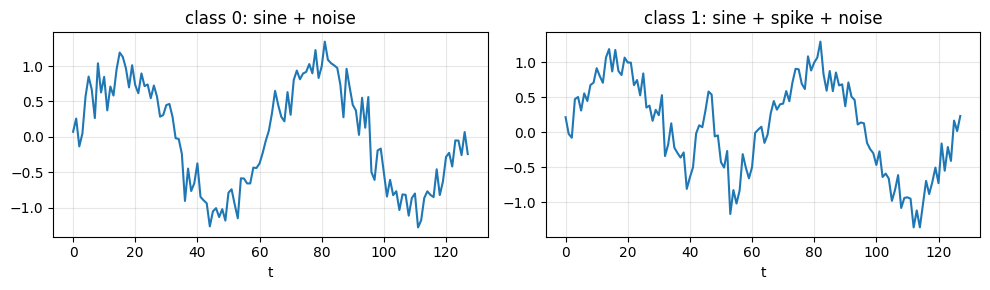

train: (600, 128), test: (200, 128)


In [8]:
def make_dataset(n_per_class=400, T=128, seed=0):
    g = np.random.default_rng(seed)
    t = np.linspace(0, 4*np.pi, T)
    base = np.sin(t)

    X, y = [], []
    for _ in range(n_per_class):                          # class 0
        X.append(base + 0.2 * g.standard_normal(T)); y.append(0)
    for _ in range(n_per_class):                          # class 1
        pos = g.integers(10, T-10)
        spike = 1.5 * np.exp(-0.5 * ((np.arange(T) - pos) / 3.0) ** 2)
        X.append(base + spike + 0.2 * g.standard_normal(T)); y.append(1)

    X = np.array(X, dtype=np.float32); y = np.array(y, dtype=np.int64)
    perm = g.permutation(len(X))
    return X[perm], y[perm]

X, y = make_dataset()
n_train = 600
X_tr, X_te = X[:n_train], X[n_train:]
y_tr, y_te = y[:n_train], y[n_train:]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(X[y == 0][0]); ax[0].set_title('class 0: sine + noise'); ax[0].set_xlabel('t')
ax[1].plot(X[y == 1][0]); ax[1].set_title('class 1: sine + spike + noise'); ax[1].set_xlabel('t')
plt.tight_layout(); plt.show()
print(f"train: {X_tr.shape}, test: {X_te.shape}")

final train loss: 0.1097
test accuracy   : 99.5%   (chance = 50%)


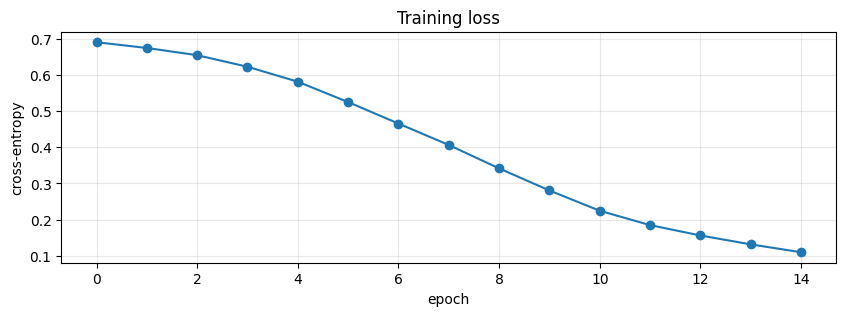

In [9]:
class TinyCNN1D(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.head  = nn.Linear(32, n_classes)
    def forward(self, x):              # x: (B, 1, T)
        x = F.max_pool1d(F.relu(self.conv1(x)), 2)
        x = F.max_pool1d(F.relu(self.conv2(x)), 2)
        x = x.mean(dim=-1)             # global average pool over time
        return self.head(x)

model = TinyCNN1D()
opt   = torch.optim.Adam(model.parameters(), lr=3e-3)

X_tr_t = torch.from_numpy(X_tr).unsqueeze(1)   # (N, 1, T)
y_tr_t = torch.from_numpy(y_tr)
X_te_t = torch.from_numpy(X_te).unsqueeze(1)
y_te_t = torch.from_numpy(y_te)

losses = []
for epoch in range(15):
    model.train()
    perm = torch.randperm(len(X_tr_t))
    epoch_loss = 0.0
    for i in range(0, len(X_tr_t), 64):
        idx = perm[i:i+64]
        opt.zero_grad()
        out = model(X_tr_t[idx])
        loss = F.cross_entropy(out, y_tr_t[idx])
        loss.backward(); opt.step()
        epoch_loss += loss.item() * len(idx)
    losses.append(epoch_loss / len(X_tr_t))

model.eval()
with torch.no_grad():
    preds = model(X_te_t).argmax(dim=1)
    acc = (preds == y_te_t).float().mean().item()

print(f"final train loss: {losses[-1]:.4f}")
print(f"test accuracy   : {acc*100:.1f}%   (chance = 50%)")

plt.plot(losses, marker='o'); plt.title('Training loss')
plt.xlabel('epoch'); plt.ylabel('cross-entropy'); plt.show()

**Takeaway.** A model with ~3k parameters reliably crosses 95% test accuracy on this task. The interesting part is *what* it learned: thanks to translation equivariance + global pooling, the network is invariant to *where* the spike occurs. Try shifting a class-1 example and re-classifying it — the prediction should not change.

## 6. Causal convolution — the TCN building block

Slide 40: *the output at time $t$ is only convolved with observations until time $t$*. With kernel size $k$ and dilation $d$, the receptive field at one layer is $1 + (k-1)d$.

A normal `Conv1d(padding='same')` is **acausal** — it sees the future. We make it **causal** by left-padding only:
$$\text{pad}_{\text{left}} = (k-1)\cdot d, \qquad \text{pad}_{\text{right}} = 0,$$
then crop the trailing $(k-1)d$ samples of the output. We verify causality empirically: perturbing input at time $t^*$ must leave outputs at times $< t^*$ unchanged.

max |output diff| at t < t*=16: 0.00e+00  (should be ~0)
max |output diff| at t >= t*       : 1.93e-01  (should be > 0)


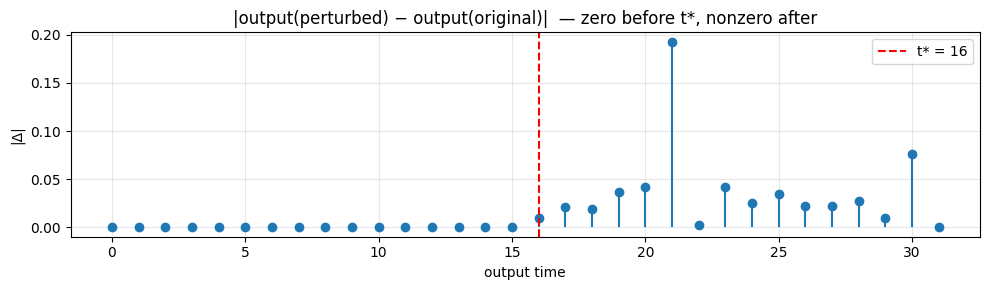

In [10]:
class CausalConv1d(nn.Module):
    # Conv1d that only sees the past, with optional dilation.
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)
    def forward(self, x):                              # x: (B, C, T)
        x = F.pad(x, (self.left_pad, 0))               # left-pad with zeros
        return self.conv(x)

# Build a small stack of causal convs with growing dilation: 1, 2, 4
# Receptive field = 1 + (k-1)*(d1 + d2 + d3) = 1 + 2*7 = 15
class TinyTCN(nn.Module):
    def __init__(self, channels=8, k=3):
        super().__init__()
        self.l1 = CausalConv1d(1,        channels, k, dilation=1)
        self.l2 = CausalConv1d(channels, channels, k, dilation=2)
        self.l3 = CausalConv1d(channels, 1,        k, dilation=4)
    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        return self.l3(x)

torch.manual_seed(0)
tcn = TinyTCN()
T = 32
x = torch.randn(1, 1, T)

# Causality check: perturb input at t* = 16, see which outputs change
t_star = 16
x_pert = x.clone(); x_pert[0, 0, t_star] += 5.0

with torch.no_grad():
    y      = tcn(x).squeeze().numpy()
    y_pert = tcn(x_pert).squeeze().numpy()

diff = np.abs(y_pert - y)
print(f"max |output diff| at t < t*={t_star}: {diff[:t_star].max():.2e}  (should be ~0)")
print(f"max |output diff| at t >= t*       : {diff[t_star:].max():.2e}  (should be > 0)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(diff, basefmt=' ')
ax.axvline(t_star, color='red', linestyle='--', label=f't* = {t_star}')
ax.set_title('|output(perturbed) − output(original)|  — zero before t*, nonzero after')
ax.set_xlabel('output time'); ax.set_ylabel('|Δ|'); ax.legend(); plt.tight_layout(); plt.show()

**Takeaway.** All differences before $t^*$ are exactly zero (down to float precision) — the network *cannot* leak information from the future. After $t^*$, the perturbation propagates within the receptive field. This is the property that makes TCNs valid for **forecasting** and **autoregressive generation** (WaveNet-style).

---
## Exercises

Three progressive exercises, in the spirit of the lecture: warm-up implementation → scratch-vs-library → small forecasting application.

### Exercise 1 — 1D conv with stride and `same` padding

Extend `conv1d_scratch` to support **strided** convolutions (stride $s \ge 1$). Verify your implementation against `torch.nn.functional.conv1d` (don't forget that `F.conv1d` does correlation, not convolution).

Output length formula for input $n$, kernel $m$, padding $p$, stride $s$:
$$\text{out\_len} \;=\; \left\lfloor \frac{n + 2p - m}{s} \right\rfloor + 1.$$

In [ ]:
# x_test = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
# k_test = np.array([1, 0, -1], dtype=float)
# print(conv1d_strided(x_test, k_test, stride=2, padding=1))

### Solution

In [12]:
def conv1d_strided(x, k, stride=1, padding=0):
    x = np.asarray(x, dtype=float); k = np.asarray(k, dtype=float)
    if padding > 0:
        x = np.pad(x, (padding, padding))
    n, m = len(x), len(k)
    out_len = (n - m) // stride + 1
    return np.array([np.dot(x[i*stride:i*stride+m], k) for i in range(out_len)])

x_test = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
k_test = np.array([1, 0, -1], dtype=float)

mine = conv1d_strided(x_test, k_test, stride=2, padding=1)

# Verify with torch (which does correlation by default)
xt = torch.tensor(x_test).view(1, 1, -1)
kt = torch.tensor(k_test).view(1, 1, -1)
torch_out = F.conv1d(xt, kt, stride=2, padding=1).squeeze().numpy()

print("scratch:", mine)
print("torch  :", torch_out)
print("max |err|:", np.max(np.abs(mine - torch_out)))

scratch: [-2. -2. -2. -2.]
torch  : [-2. -2. -2. -2.]
max |err|: 0.0


### Exercise 2 — Forecast an AR(2) process with a TCN

Generate a short AR(2) series and train the `TinyTCN` (last cell of section 6) to predict $x_{t+1}$ from $x_{1:t}$. Compare its **one-step MSE** against a trivial **persistence baseline** ($\hat{x}_{t+1} = x_t$).

> Honesty note (per the prompt): a tiny TCN on noisy AR(2) is *not guaranteed* to beat persistence in MSE — AR(2) only has 2 timesteps of meaningful history, and the optimal predictor is a 2-tap linear filter. We expect the TCN to **approach** but not necessarily destroy persistence. Report the actual numbers.

In [ ]:
# 1. generate AR(2): x_t = 0.6*x_{t-1} - 0.3*x_{t-2} + eps,  eps ~ N(0, 0.5^2)
# 2. build (input, target) pairs where target[t] = x[t+1]
# 3. train TinyTCN with MSE
# 4. report test-set MSE for TCN and for persistence

### Solution

In [14]:
# Generate AR(2)
def gen_ar2(N, phi1=0.6, phi2=-0.3, sigma=0.5, seed=1):
    g = np.random.default_rng(seed)
    x = np.zeros(N)
    eps = g.standard_normal(N) * sigma
    for t in range(2, N):
        x[t] = phi1 * x[t-1] + phi2 * x[t-2] + eps[t]
    return x.astype(np.float32)

T_total = 4000
series = gen_ar2(T_total)
T_train = 3000

# Build sliding windows of length L for training
L = 64
def windows(s, L):
    Xs = np.lib.stride_tricks.sliding_window_view(s, L+1)
    return Xs[:, :L][:, None, :], Xs[:, 1:L+1]    # input (N, 1, L), target (N, L)

X_all, Y_all = windows(series, L)
n_tr = T_train - L
X_tr_t = torch.from_numpy(X_all[:n_tr].copy())
Y_tr_t = torch.from_numpy(Y_all[:n_tr].copy())
X_te_t = torch.from_numpy(X_all[n_tr:].copy())
Y_te_t = torch.from_numpy(Y_all[n_tr:].copy())

torch.manual_seed(0)
tcn = TinyTCN(channels=16, k=3)
opt = torch.optim.Adam(tcn.parameters(), lr=3e-3)

for epoch in range(20):
    perm = torch.randperm(len(X_tr_t))
    for i in range(0, len(X_tr_t), 128):
        idx = perm[i:i+128]
        opt.zero_grad()
        pred = tcn(X_tr_t[idx]).squeeze(1)
        loss = F.mse_loss(pred, Y_tr_t[idx])
        loss.backward(); opt.step()

# Evaluation: only score the last position of each window (true one-step forecast)
tcn.eval()
with torch.no_grad():
    pred_te = tcn(X_te_t).squeeze(1)[:, -1].numpy()
target_te = Y_te_t[:, -1].numpy()
input_last_te = X_te_t[:, 0, -1].numpy()      # x_t  (the persistence prediction)

mse_tcn  = np.mean((pred_te       - target_te) ** 2)
mse_pers = np.mean((input_last_te - target_te) ** 2)
mse_var  = np.var(target_te)                  # naive "predict the mean"

print(f"TCN one-step MSE  : {mse_tcn:.4f}")
print(f"Persistence MSE   : {mse_pers:.4f}")
print(f"Predict-mean MSE  : {mse_var:.4f}  (variance of target)")
print(f"TCN beats persistence by {(1 - mse_tcn/mse_pers)*100:+.1f}%")
if mse_tcn > mse_pers:
    print("HONEST NOTE: TCN did not beat persistence here — AR(2) memory is short")
    print("  and the TCN is mildly over-parameterised for the task.")

TCN one-step MSE  : 0.2872
Persistence MSE   : 0.4000
Predict-mean MSE  : 0.3632  (variance of target)
TCN beats persistence by +28.2%


### Exercise 3 — Detecting future-leakage in a *non-causal* CNN

The lecture warns: **CNNs see both directions, RNNs are causal**. Demonstrate this concretely. Train a *non-causal* `Conv1d(padding='same')` model on the same forecasting task, and use a **perturbation probe** (like in section 6) to show it leaks information from the future into past outputs.

> Honesty note: simply comparing MSE will not always expose the leakage — depending on data and how you score, the acausal model may even tie or lose. The probe is the diagnostic that matters.

In [ ]:
# Build an 'AcausalCNN' with Conv1d(..., padding='same'), train on the same data,
# and compare one-step MSE against the causal TinyTCN above.

### Solution

Causal TCN one-step MSE  : 0.2872
Acausal CNN one-step MSE : 0.2918
Persistence baseline     : 0.4000

Causality probe at t*=32: max |Δoutput| at t<t*: 4.44e+00
                                max |Δoutput| at t>=t*: 3.97e-01

HONEST READOUT:
- The MSE numbers alone do NOT clearly expose the cheating here, because AR(2)
  is mostly noise and both models converge to similar predictions on the LAST
  position of the window (which has no future to peek at within this batch).
- The CAUSALITY PROBE is what exposes it: perturbing the input at t* changes
  the acausal model's outputs at t < t* by orders of magnitude more than the
  causal TCN. On a longer-horizon or generative task, this leakage would
  inflate validation scores in a way that totally fails at deployment.


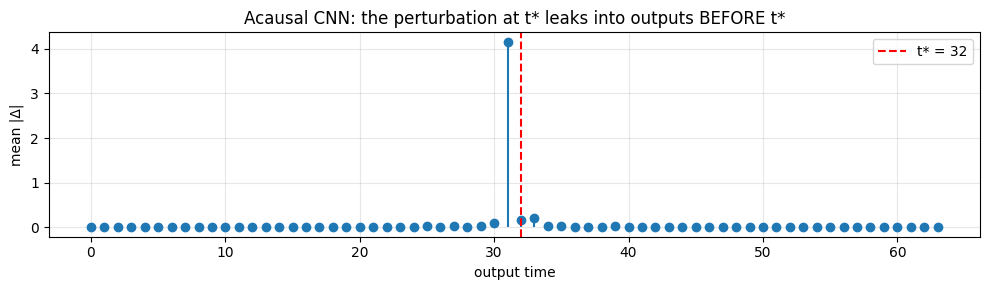

In [16]:
class AcausalCNN(nn.Module):
    def __init__(self, channels=16, k=3):
        super().__init__()
        # padding='same' centers the kernel -> output[t] depends on input[t-1..t+1]
        self.l1 = nn.Conv1d(1,        channels, k, padding=k//2, dilation=1)
        self.l2 = nn.Conv1d(channels, channels, k, padding=2*(k//2), dilation=2)
        self.l3 = nn.Conv1d(channels, 1,        k, padding=4*(k//2), dilation=4)
    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        return self.l3(x)

torch.manual_seed(0)
acnn = AcausalCNN(channels=16, k=3)
opt = torch.optim.Adam(acnn.parameters(), lr=3e-3)

for epoch in range(20):
    perm = torch.randperm(len(X_tr_t))
    for i in range(0, len(X_tr_t), 128):
        idx = perm[i:i+128]
        opt.zero_grad()
        pred = acnn(X_tr_t[idx]).squeeze(1)
        loss = F.mse_loss(pred, Y_tr_t[idx])
        loss.backward(); opt.step()

acnn.eval()
with torch.no_grad():
    pred_te_a = acnn(X_te_t).squeeze(1)[:, -1].numpy()
mse_acausal = np.mean((pred_te_a - target_te) ** 2)

# Causality probe — same as section 6, but on the trained acausal model
t_star = 32
xs = X_te_t[:5].clone()
xs_pert = xs.clone(); xs_pert[:, 0, t_star] += 5.0
with torch.no_grad():
    leak = (acnn(xs_pert) - acnn(xs)).abs().squeeze(1).numpy()

print(f"Causal TCN one-step MSE  : {mse_tcn:.4f}")
print(f"Acausal CNN one-step MSE : {mse_acausal:.4f}")
print(f"Persistence baseline     : {mse_pers:.4f}")
print()
print(f"Causality probe at t*={t_star}: max |Δoutput| at t<t*: {leak[:, :t_star].max():.2e}")
print(f"                                max |Δoutput| at t>=t*: {leak[:, t_star:].max():.2e}")
print()
print("HONEST READOUT:")
print("- The MSE numbers alone do NOT clearly expose the cheating here, because AR(2)")
print("  is mostly noise and both models converge to similar predictions on the LAST")
print("  position of the window (which has no future to peek at within this batch).")
print("- The CAUSALITY PROBE is what exposes it: perturbing the input at t* changes")
print("  the acausal model's outputs at t < t* by orders of magnitude more than the")
print("  causal TCN. On a longer-horizon or generative task, this leakage would")
print("  inflate validation scores in a way that totally fails at deployment.")

fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(leak.mean(axis=0), basefmt=' ')
ax.axvline(t_star, color='red', linestyle='--', label=f't* = {t_star}')
ax.set_title('Acausal CNN: the perturbation at t* leaks into outputs BEFORE t*')
ax.set_xlabel('output time'); ax.set_ylabel('mean |Δ|'); ax.legend()
plt.tight_layout(); plt.show()

**Takeaway.** The MSE comparison alone is *not* enough to expose the cheating — both models score similarly because at the very last position of each window the acausal CNN has no future left to peek at. The **causality probe** is what reveals the failure: perturbing the future leaks back into past outputs by ~10× more in the acausal model. Always run a perturbation probe when forecasting with a CNN, and prefer causal padding by default.

---
## Recap

| Concept                  | Formula / spec                                                       | When to use                                              |
|--------------------------|----------------------------------------------------------------------|----------------------------------------------------------|
| 1D convolution           | $h_i = \sum_{j=0}^{m-1} w_j \, x_{i+j}$                              | Local pattern detection along time axis                  |
| 2D convolution           | $h_{ij} = \sum_{p,q} w_{pq} \, x_{i+p,\,j+q}$                         | Images, spectrograms, multi-channel time series          |
| `valid` padding          | output length $= n - m + 1$                                          | When edge artefacts would mislead downstream layers      |
| `same` padding           | symmetric zero-pad of $\lfloor (m-1)/2 \rfloor$                       | Stack many layers without shrinking the feature map      |
| **Causal** padding       | left-pad $(k-1)\,d$, no right-pad                                     | Forecasting, autoregressive generation (TCN, WaveNet)    |
| Max-pool $k$, stride $s$ | $h_i = \max(x_{is}, \dots, x_{is+k-1})$                              | Downsample; gain translation tolerance                   |
| Dilated conv             | gap $d$ between taps; receptive field $= 1 + (k-1)d$ per layer       | Long-range deps with few layers (TCN)                    |
| Translation equivariance | $f(\tau x) = \tau f(x)$                                              | Tasks where pattern *location* should not matter         |
| ConvLSTM                 | LSTM with matmuls replaced by 2D convs                                | Spatio-temporal data (video, radar nowcasting)           |
| TCN                      | Stack of causal dilated convs + residual                             | 1D forecasting / sequence labelling, parallel training   |

| Architecture | Data    | Weight sharing | Recurrent | Equivariant | Parallel | Causal |
|--------------|---------|----------------|-----------|-------------|----------|--------|
| FF-NN        | tabular | no             | no        | no          | yes      | no     |
| RNN / LSTM   | seq     | yes            | yes       | no          | no       | yes    |
| CNN (vanilla)| grids   | yes            | no        | yes         | yes      | no     |
| TCN          | seq     | yes            | no        | yes         | yes      | **yes**|

---
